# Adversarial Transferability on ImageNet: ResNet-18 to ResNet-50

**Objective.** Craft adversarial examples with white-box PGD on a local **ResNet-18** (the substitute) and test whether they fool a **ResNet-50** that we can only query (the black-box target, standing in for a model behind a website or third-party API). Both are pretrained ImageNet classifiers, and the test images are 10 random pictures downloaded from the internet.

## What you will do

1. Load two pretrained ImageNet models, ResNet-18 (local substitute) and ResNet-50 (hidden behind a query-only API).
2. Download 10 random images from the internet, each belonging to one of the 1,000 ImageNet classes, and prepare them for the models (resize to 256, center-crop 224).
3. Run the white-box PGD attack, with the Adversarial Robustness Toolbox (ART), against ResNet-18.
4. Send the adversarial images to the ResNet-50 API and count how many fool it: the cross-model **transfer fooling rate**.
5. Visualize the images, the perturbations, and the change in confidence, then sweep the attack strength.

## Prerequisites

- Comfortable with CNN image classifiers, softmax probabilities, and the L-infinity norm.
- Familiar with the white-box PGD attack. Transferability is what lets a white-box attack be used against a model you cannot differentiate.

## Running this notebook

This notebook loads pretrained models and downloads its images, so it needs internet access; no local files are required. Run the cells top to bottom, on Colab or locally. A GPU speeds it up but is not required.

## Background: transferability at ImageNet scale

An adversarial example crafted against one model is often misclassified by a different model, even one with a different architecture or training run. Two hypotheses explain it:

- **Shared features.** Models trained on the same task learn similar *non-robust* features, patterns that correlate with the label but that humans ignore. A perturbation that flips the substitute by disturbing such a feature also flips any model that relies on it.
- **Aligned decision boundaries.** Around a given image, the decision boundaries of different models trained on the same data are in similar places, so a step across one model's boundary along a gradient direction often crosses the other's.

**The threat model.** The attacker never sees the target's weights or gradients. They attack a model they own and hope the perturbation carries over:

| | Substitute (local) | Target (API side) |
|---|---|---|
| Model | ResNet-18 (pretrained, about 11.7M parameters) | ResNet-50 (pretrained, about 25.6M parameters) |
| What the attacker can do | Everything: read weights, compute gradients | Query only: send images, receive logits and probabilities |
| Role | Where PGD runs | Where we measure transfer |

In the classic substitute attack the attacker trains the local model themselves, using labels obtained by querying the target. Here a pretrained ResNet-18 plays the role of that local model.

**Model families.** ResNet-18 and ResNet-50 share the same design (residual blocks) and differ in depth, so they are *closely related* architectures. Transfer between closely related models is typically higher than between different families; the assignment asks you to test this.

## 1. Setup

Install the Adversarial Robustness Toolbox (ART), then import the libraries. PyTorch, torchvision, NumPy, and Matplotlib are usually already available (e.g. on Colab); ART is not, so we install it here.

In [2]:
# ART (Adversarial Robustness Toolbox) provides the PGD attack.
# PyTorch, torchvision, and Matplotlib are usually pre-installed (e.g. on Colab);
# uncomment the second line if your environment is missing them.
!pip install adversarial-robustness-toolbox requests pillow
# !pip install torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.0 MB/s eta 0:00:00


In [3]:
import io
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import requests
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms
from matplotlib import pyplot as plt

# ART components used in this notebook:
# - PyTorchClassifier wraps a PyTorch model in ART's estimator interface.
# - ProjectedGradientDescent is the PGD evasion attack.
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import ProjectedGradientDescent

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


## 2. Load the two pretrained models

We load ResNet-18 and ResNet-50 with their standard ImageNet weights from torchvision, and take the 1,000 ImageNet class names from the weights' metadata.

Both models expect inputs normalized with the ImageNet mean and standard deviation. We fold that normalization *inside* a small wrapper module, so that the attack works directly in `[0, 1]` pixel space: the perturbation budget `eps` and the `clip_values` are then expressed in ordinary pixel units (for example `16/255` means each pixel may change by at most 16 of 255 intensity levels).

The ResNet-50 is then placed behind `BlackBoxAPI`, which accepts images and returns only **logits** and **probabilities**. We `del` the direct reference so the rest of the notebook can only use it as a query oracle. The API counts queries, since query volume is what an API owner can monitor.

In [4]:
weights18 = models.ResNet18_Weights.IMAGENET1K_V1
weights50 = models.ResNet50_Weights.IMAGENET1K_V1
categories = weights18.meta["categories"]   # the 1,000 ImageNet class names, in class-index order


class Normalized(nn.Module):
    # Wraps a model so it accepts [0, 1] images and applies the ImageNet normalization internally.
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        return self.model((x - self.mean) / self.std)   # logits


def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


class BlackBoxAPI:
    # Mimics a hosted model: send images in, get logits and probabilities back. Nothing else.
    def __init__(self, model):
        self._model = model.eval()
        self.query_count = 0

    @torch.no_grad()
    def query(self, x):
        self.query_count += len(x)
        logits = self._model(torch.as_tensor(x, dtype=torch.float32, device=device)).cpu().numpy()
        return logits, softmax(logits)


substitute = Normalized(models.resnet18(weights=weights18)).eval().to(device)   # local model: we may differentiate it
target_net = Normalized(models.resnet50(weights=weights50)).eval().to(device)   # hidden model

api = BlackBoxAPI(target_net)
del target_net   # from here on the attacker only has the API

print("Substitute: ResNet-18 (local, white-box access)")
print("Target:     ResNet-50 (black-box API, query only)")
print("Number of ImageNet classes:", len(categories))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 58.2MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 51.1MB/s]


Substitute: ResNet-18 (local, white-box access)
Target:     ResNet-50 (black-box API, query only)
Number of ImageNet classes: 1000


## 3. Get 10 random images from the internet

We need real images with a **known true label that is one of the 1,000 ImageNet classes**; an image of something outside those classes cannot be classified correctly by either model, which would make the experiment meaningless.

The public GitHub repository `EliSchwartz/imagenet-sample-images` hosts exactly one sample image per ImageNet class. Each file name starts with the class's WordNet ID (for example `n01440764_tench.JPEG`), and ImageNet's 1,000 class indices are simply the WordNet IDs in sorted order. Listing the repository therefore gives us, for every class index, the URL of an image of that class, so the true label is always valid.

### Preparing an image

Each image is loaded as RGB, resized so its shorter side is 256 pixels, then center-cropped to `224 x 224` (the size the ResNets expect), and scaled to `[0, 1]`.

In [5]:
REPO = "EliSchwartz/imagenet-sample-images"

# One file per ImageNet class. Sorted by WordNet ID = ImageNet class-index order.
tree = requests.get(f"https://api.github.com/repos/{REPO}/git/trees/master", timeout=30).json()
files = sorted(t["path"] for t in tree["tree"] if t["path"].upper().endswith(".JPEG"))
assert len(files) == 1000, f"expected 1000 class images, found {len(files)}"
print("First three files:", files[:3])
print("First three ImageNet classes:", categories[:3])

# Resize the shorter side to 256, then center-crop 224x224, then scale pixels to [0, 1].
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

def load_image(class_idx):
    url = f"https://raw.githubusercontent.com/{REPO}/master/{files[class_idx]}"
    img = Image.open(io.BytesIO(requests.get(url, timeout=30).content)).convert("RGB")
    return preprocess(img).numpy()   # (3, 224, 224), float32 in [0, 1]

@torch.no_grad()
def logits_of(model, x):
    return model(torch.as_tensor(x, dtype=torch.float32, device=device)).cpu().numpy()

First three files: ['n01440764_tench.JPEG', 'n01443537_goldfish.JPEG', 'n01484850_great_white_shark.JPEG']
First three ImageNet classes: ['tench', 'goldfish', 'great white shark']


### Draw 10 random classes

We draw classes in random order (fixed seed) and download one image per class. We keep an image only if **both** models classify its *clean* version correctly. That way, if an adversarial version is later misclassified, the attack is the cause and not a hard or ambiguous picture. We stop when we have 10.

In [6]:
rng = np.random.default_rng(SEED)

x_list, y_list, tried = [], [], 0
for class_idx in rng.permutation(1000):
    try:
        x = load_image(class_idx)[None]
    except Exception as err:   # skip an image that fails to download or decode
        print(f"skipped class {class_idx}: {err}")
        continue
    tried += 1
    sub_ok = logits_of(substitute, x).argmax(1)[0] == class_idx
    api_ok = api.query(x)[0].argmax(1)[0] == class_idx
    if sub_ok and api_ok:
        x_list.append(x[0])
        y_list.append(int(class_idx))
    if len(x_list) == 10:
        break

x_sel = np.stack(x_list).astype('float32')   # (10, 3, 224, 224)
y_sel = np.array(y_list)
print(f"Downloaded {tried} images to find 10 that both models classify correctly.")
print("True classes:", [categories[i] for i in y_sel])

Downloaded 13 images to find 10 that both models classify correctly.
True classes: ['kuvasz', 'beagle', 'perfume', 'speedboat', 'ibex', 'volleyball', 'crash helmet', 'oboe', 'mousetrap', 'convertible']


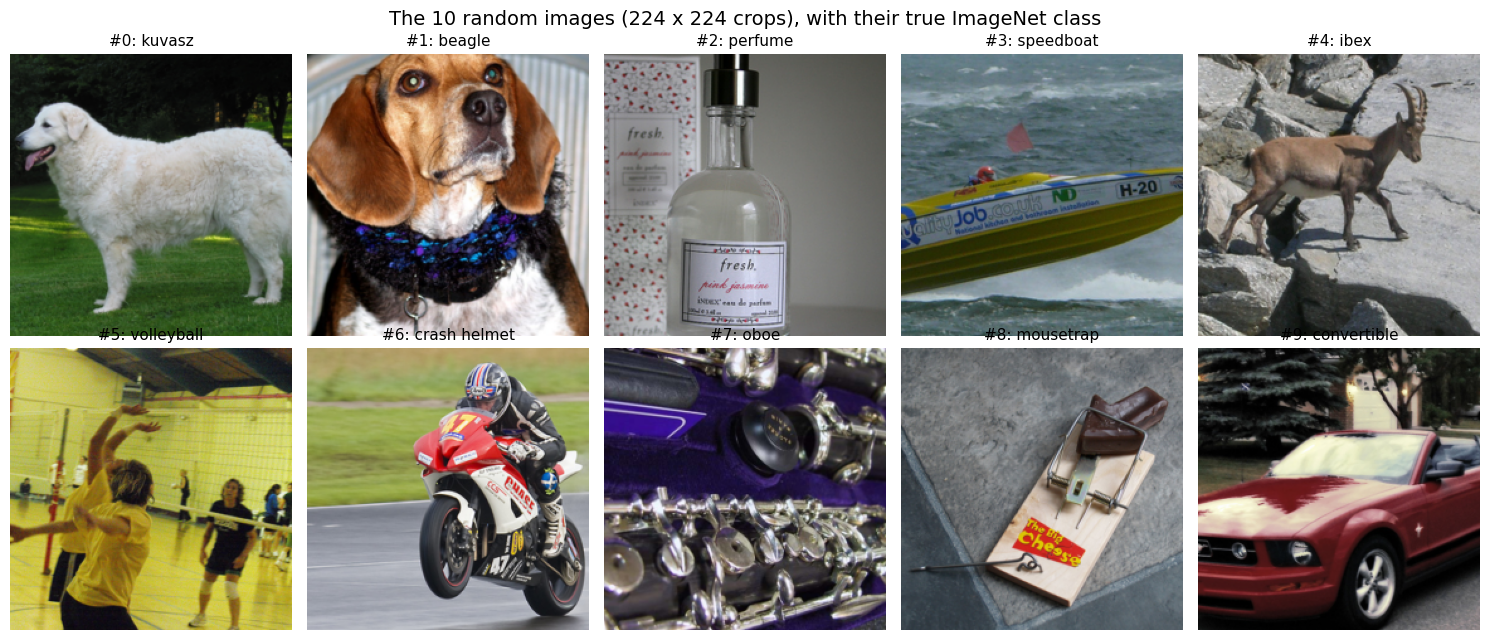

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for k, ax in enumerate(axes.flatten()):
    ax.imshow(x_sel[k].transpose(1, 2, 0))
    ax.set_title(f"#{k}: {categories[y_sel[k]]}", fontsize=11)
    ax.axis('off')
fig.suptitle("The 10 random images (224 x 224 crops), with their true ImageNet class", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Attack ResNet-18 with PGD

### Wrap the substitute for ART

ART attacks operate on an *estimator*, not a raw PyTorch model. We wrap the **substitute** (the model we own) with `PyTorchClassifier` and declare the valid pixel range via `clip_values=(0.0, 1.0)`. The attack computes exact gradients on this model only; the ResNet-50 API is never wrapped or differentiated.

In [8]:
substitute_clf = PyTorchClassifier(
    model=substitute,
    loss=nn.CrossEntropyLoss(),
    input_shape=(3, 224, 224),
    nb_classes=1000,
    clip_values=(0.0, 1.0),
    device_type='gpu' if torch.cuda.is_available() else 'cpu',
)

### Build and run the attack

PGD's behavior is set by three parameters:

| Parameter | Role |
|-----------|------|
| `eps` | L-infinity perturbation budget: the maximum change per pixel on the `[0, 1]` scale. We use `16/255`, about 6% of the intensity range: usually invisible at a glance, and a common budget for transfer experiments on ImageNet. |
| `eps_step` | Step size per iteration. We use `eps / 8`. |
| `max_iter` | Number of gradient-ascent + projection iterations (here `20`). |

The labels passed in are the **true** classes, so the attack pushes each image away from its correct class.

In [10]:
EPS = 16 / 255
attack_pgd = ProjectedGradientDescent(
    estimator=substitute_clf,
    norm=np.inf,
    eps=EPS,
    eps_step=EPS / 8,
    max_iter=20,
    num_random_init=1,
    verbose=False,
)

y_sel_onehot = np.eye(1000, dtype='float32')[y_sel]
x_adv = attack_pgd.generate(x=x_sel, y=y_sel_onehot)

print("x_adv:", x_adv.shape)
print(f"L-infinity norm of the perturbation: {np.abs(x_adv - x_sel).max() * 255:.1f} / 255  (should be <= 16)")

x_adv: (10, 3, 224, 224)
L-infinity norm of the perturbation: 16.0 / 255  (should be <= 16)


## 5. Did the attack transfer?

For each image we compare four predictions: the substitute (ResNet-18) before and after the attack, and the black-box API (ResNet-50) before and after. Two counts summarize the experiment:

- **White-box success:** how many adversarial images fool ResNet-18, the model the attack was built on.
- **Transfer:** how many of *those* also fool ResNet-50, which the attacker never differentiated. The transfer rate is that count divided by the white-box successes.

In [11]:
sub_logits_clean = logits_of(substitute, x_sel)
sub_logits_adv = substitute_clf.predict(x_adv)
api_logits_clean, api_probs_clean = api.query(x_sel)
api_logits_adv, api_probs_adv = api.query(x_adv)

sub_probs_clean, sub_probs_adv = softmax(sub_logits_clean), softmax(sub_logits_adv)
sub_pred_adv = sub_logits_adv.argmax(1)
api_pred_adv = api_logits_adv.argmax(1)

name = lambda i: categories[i][:16]
print(f"{'#':>2} {'true class':<17}| {'ResNet-18 adv prediction':<26}| {'ResNet-50 adv prediction':<26}| R50 P(true): clean -> adv | fooled")
for k in range(10):
    fooled = 'YES' if api_pred_adv[k] != y_sel[k] else 'no'
    print(f"{k:>2} {name(y_sel[k]):<17}| {name(sub_pred_adv[k]):<26}| {name(api_pred_adv[k]):<26}| "
          f"{api_probs_clean[k, y_sel[k]]:>10.3f} -> {api_probs_adv[k, y_sel[k]]:<7.3f} | {fooled}")

sub_fooled = sub_pred_adv != y_sel
api_fooled = api_pred_adv != y_sel
n_sub, n_api, n_both = int(sub_fooled.sum()), int(api_fooled.sum()), int((sub_fooled & api_fooled).sum())
print(f"\nResNet-18 fooled (white-box): {n_sub} / 10")
print(f"ResNet-50 fooled (transfer):  {n_api} / 10")
print(f"Transfer rate (ResNet-50 fooled | ResNet-18 fooled): {n_both / max(n_sub, 1) * 100:.0f}%")
print("Total API queries used:", api.query_count)

 # true class       | ResNet-18 adv prediction  | ResNet-50 adv prediction  | R50 P(true): clean -> adv | fooled
 0 kuvasz           | standard schnauz          | kuvasz                    |      1.000 -> 0.537   | no
 1 beagle           | bluetick                  | bluetick                  |      0.917 -> 0.005   | YES
 2 perfume          | soap dispenser            | lotion                    |      0.578 -> 0.081   | YES
 3 speedboat        | rubber eraser             | airship                   |      1.000 -> 0.055   | YES
 4 ibex             | cricket                   | ibex                      |      1.000 -> 0.885   | no
 5 volleyball       | padlock                   | padlock                   |      1.000 -> 0.015   | YES
 6 crash helmet     | go-kart                   | crash helmet              |      0.998 -> 0.989   | no
 7 oboe             | perfume                   | oboe                      |      0.994 -> 0.351   | no
 8 mousetrap        | holster              

## 6. Visualize the images, the perturbations, and the confidence change

Top row: the clean images. Middle row: the adversarial images. Bottom row: the perturbation, amplified so it is visible (gray = no change). Titles show the prediction of each model (green = correct, red = wrong). The images look unchanged to us, yet many predictions flip.

In [12]:
fig, axes = plt.subplots(3, 10, figsize=(24, 8.5))
for k in range(10):
    sub_c, api_c = sub_logits_clean[k].argmax(), api_logits_clean[k].argmax()
    axes[0, k].imshow(x_sel[k].transpose(1, 2, 0))
    axes[0, k].set_title(f"clean: {name(y_sel[k])}\nR18 {name(sub_c)}\nR50 {name(api_c)}", fontsize=8,
                         color='green' if sub_c == y_sel[k] and api_c == y_sel[k] else 'red')

    axes[1, k].imshow(np.clip(x_adv[k].transpose(1, 2, 0), 0, 1))
    axes[1, k].set_title(f"PGD\nR18 {name(sub_pred_adv[k])}\nR50 {name(api_pred_adv[k])}", fontsize=8,
                         color='green' if not sub_fooled[k] and not api_fooled[k] else 'red')

    delta = (x_adv[k] - x_sel[k]).transpose(1, 2, 0)
    axes[2, k].imshow(np.clip(delta / (2 * EPS) + 0.5, 0, 1))
    axes[2, k].set_title("perturbation (amplified)", fontsize=8)
    for row in range(3):
        axes[row, k].axis('off')
fig.suptitle("Clean (top), PGD adversarial (middle), and perturbation (bottom)", fontsize=14)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Confidence in the true class

For each image, the probability each model assigns to the **true** class, before and after the attack. A tall bar means the model is confident and correct. The attack collapses ResNet-18's bar (it was built for that), and the ResNet-50 bars show how far the perturbation pushed a model that never took part in crafting it, even where its prediction did not fully flip.

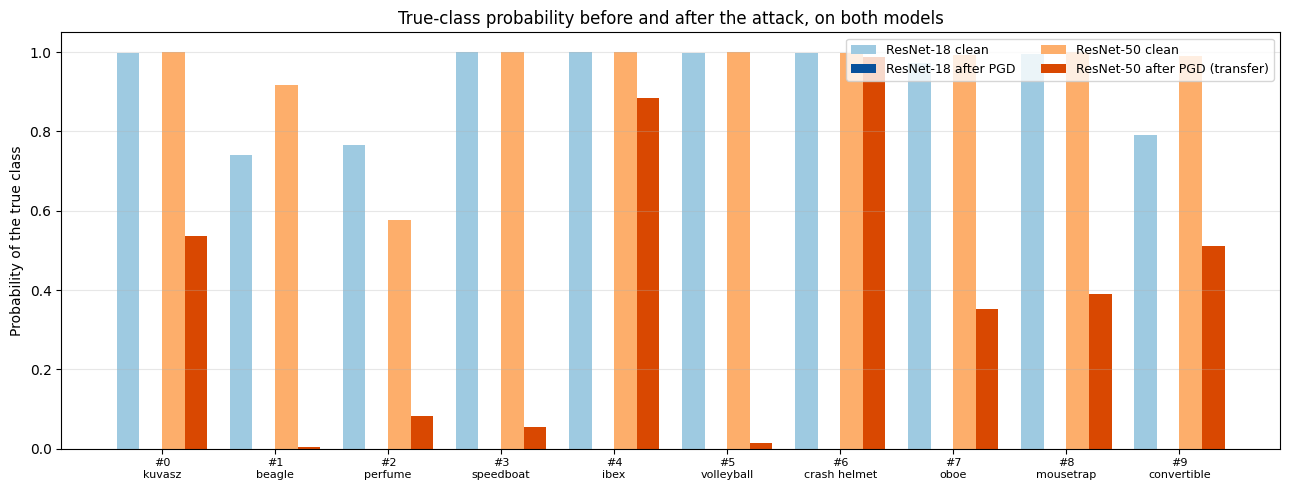

In [13]:
idx = np.arange(10)
bars = [
    ("ResNet-18 clean", sub_probs_clean[idx, y_sel], '#9ecae1'),
    ("ResNet-18 after PGD", sub_probs_adv[idx, y_sel], '#08519c'),
    ("ResNet-50 clean", api_probs_clean[idx, y_sel], '#fdae6b'),
    ("ResNet-50 after PGD (transfer)", api_probs_adv[idx, y_sel], '#d94801'),
]

fig, ax = plt.subplots(figsize=(13, 5))
for j, (label, values, color) in enumerate(bars):
    ax.bar(idx + (j - 1.5) * 0.2, values, width=0.2, label=label, color=color)
ax.set_xticks(idx)
ax.set_xticklabels([f"#{k}\n{name(y_sel[k])}" for k in idx], fontsize=8)
ax.set_ylabel("Probability of the true class")
ax.set_ylim(0, 1.05)
ax.set_title("True-class probability before and after the attack, on both models")
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## 7. Transfer versus attack strength

Ten images make a vivid story but a coarse statistic. To see how transfer depends on the perturbation budget, we repeat the attack on the same 10 images at several values of `eps` (in units of `1/255`) and count how many fool each model. Counts on 10 images are noisy, so read the *trend* rather than the exact values.

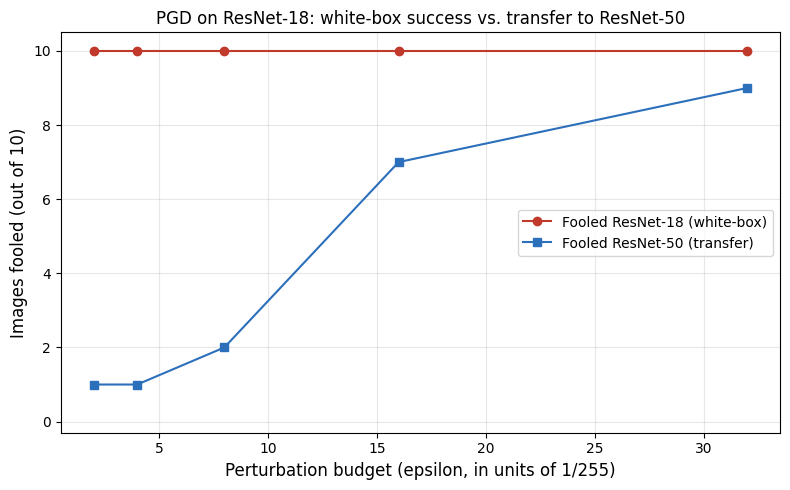

In [15]:
eps_range = [2, 4, 8, 16, 32]   # in units of 1/255
n_sub_list, n_api_list = [], []
for e in eps_range:
    attack_pgd.set_params(eps=e / 255, eps_step=e / 255 / 8)
    x_e = attack_pgd.generate(x=x_sel, y=y_sel_onehot)
    n_sub_list.append(int((substitute_clf.predict(x_e).argmax(1) != y_sel).sum()))
    n_api_list.append(int((api.query(x_e)[0].argmax(1) != y_sel).sum()))
attack_pgd.set_params(eps=EPS, eps_step=EPS / 8)   # restore the main attack settings

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_range, n_sub_list, marker='o', color='#c0392b', label='Fooled ResNet-18 (white-box)')
ax.plot(eps_range, n_api_list, marker='s', color='#2c6fbb', label='Fooled ResNet-50 (transfer)')
ax.set_xlabel('Perturbation budget (epsilon, in units of 1/255)', fontsize=12)
ax.set_ylabel('Images fooled (out of 10)', fontsize=12)
ax.set_ylim(-0.3, 10.5)
ax.set_title('PGD on ResNet-18: white-box success vs. transfer to ResNet-50', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='center right', fontsize=10)
plt.tight_layout()
plt.show()

> **Takeaway.** The white-box attack fools ResNet-18 at small budgets, but ResNet-50, which the attacker never differentiated, needs a larger budget before it starts to break, and the transfer curve stays at or below the white-box curve. The perturbation is partly specific to the substitute and partly shared with the target; the shared part is what transfers.

## Key takeaways

- **Adversarial examples transfer between pretrained ImageNet models.** Perturbations computed only from ResNet-18's gradients fool a ResNet-50 that was reachable only through a query interface, because the two models rely on overlapping non-robust features and have aligned decision boundaries.
- **Hiding the model is not enough.** The attacker needed the API only to check the outcome. All gradients came from a public pretrained model they could download.
- **Transfer depends on the budget.** A larger `eps` produces more transfer, but also a more visible perturbation.
- **Closely related models transfer best.** ResNet-18 and ResNet-50 share a design, so this is a favorable case for the attacker; transfer to a different model family is typically harder.
- **Always attack valid classes.** The images came from the ImageNet label set and were classified correctly when clean, so every flipped prediction is attributable to the perturbation.

## Assignment

Complete each item directly in this notebook, re-running from that point forward.

1. Replace the ResNet-50 target with a different model family (for example `models.vgg16` or `models.densenet121` with their `IMAGENET1K_V1` weights, wrapped in `Normalized`), and report how many of the 10 images fool it. Does the transfer rate change, and why might it?
2. Set `EPS = 4 / 255`, re-run the attack, and report the white-box success and the number of images that fool the API.
3. Increase `max_iter` from 20 to 100 and report whether white-box success and transfer change. Explain what happens when an iterative attack fits the substitute too closely.
4. Swap the roles: attack ResNet-50 locally and use ResNet-18 as the API. Which direction transfers better, and why?
5. Change `SEED` to draw a different set of 10 random classes and report the transfer rate. Why do the numbers differ between draws?
6. **(General knowledge.)** The API owner never released the ResNet-50 weights. Give one reason why keeping a model private is not enough to protect it against this attack.

You have completed this lab when you have answered 1, 4, 5, and 6, and reported your findings for 2 and 3.